# Simulate GWAS summary statistics

> **Under development** — not published in site navigation. Markdown draft: `docs/utility_simulate_sumstats.md` and `docs/SimulateSumstats.md`.

Generate simulated BETA/SE/Z/P from a reference-panel VCF using `simulate_sumstats_region` and `simulate_sumstats_global`.

**Prerequisites**
- Tabix-indexed VCF with genotypes (`GT`) and AF in INFO
- Region demos: bundled chr7 slice (`test/ref/1kg_eas_hg19.chr7_126253550_128253550.vcf.gz`), **1 Mb** window inside the slice
- Global demo: full genome via `gl.get_path("1kg_eas_hg19")` (run `gl.download_ref("1kg_eas_hg19")` once if missing)

## Load GWASLab

In [1]:
import os
import sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if not os.path.isdir(os.path.join(ROOT, "src", "gwaslab")):
    ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(ROOT, "src"))

import matplotlib.pyplot as plt
import gwaslab as gl

%matplotlib inline

gl.show_version()

2026/07/07 16:56:45 GWASLab v4.2.0 https://cloufield.github.io/gwaslab/
2026/07/07 16:56:45 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/07/07 16:56:45 Python version: 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:43:22) [GCC 12.3.0]


## Reference panel

In [2]:
vcf_path = os.path.join(ROOT, "test", "ref", "1kg_eas_hg19.chr7_126253550_128253550.vcf.gz")
region = ("7", 126753550, 127753550)  # 1 Mb, centered in bundled chr7 slice
assert os.path.isfile(vcf_path), vcf_path

# Full genome for global simulation (download once if missing)
# gl.download_ref("1kg_eas_hg19")
vcf_path_gw = gl.get_path("1kg_eas_hg19")

# Neutral API defaults; pass this dict for tutorial-style inflated/thinned output
REALISM_DEMO = dict(
    thin=0.5,
    lambda_gc=1.01,
    sigma_strat=0.05,
    n_drop_rate=0.15,
)

## How simulation works

GWASLab simulates summary statistics from a **reference-panel VCF**. Genotypes provide LD structure; variant metadata (AF/INFO) drives filtering and realism knobs.

**Inputs**

- Tabix VCF with `GT` (LD) and AF in INFO (filtering / effect scaling)
- User settings: trait type, sample size, architecture (`sparse` / `polygenic`), and realism (`lambda_gc`, `sigma_strat`, `thin`, INFO)

**Pipeline** (`simulate_sumstats_region`; see `gwaslab.util.util_in_simulate`)

1. Load variant metadata from the VCF
2. Filter by MAF/EAF; optionally thin variants (`thin`)
3. Assign per-variant `N`, `N_EFF`, and simulated `INFO`
4. Select causal variants and draw `BETA_TRUE` (MAF-dependent when `alpha > 0`)
5. Load standardized genotypes `X`; simulate Z with an efficient `X^T X` form (no full LD matrix)
6. Convert Z → `BETA`, `SE`, `P`, `MLOG10P`; mark `IS_CAUSAL`

**Core model**

```
z = μ_causal + b_strat + ε
```

- `μ_causal` — causal signal spread through LD
- `ε` — noise scaled by `lambda_gc` (cryptic relatedness)
- `b_strat` — stratification bias (`sigma_strat`)

**Region vs global**

| Function | Scope |
|----------|-------|
| `simulate_sumstats_region` | One window; fast for demos |
| `simulate_sumstats_global` | One or more chromosomes in blocks + **`h2` calibration** |

**Ground truth**

- Columns `IS_CAUSAL`, `BETA_TRUE`
- Returned list `causal_snp_ids`

Full parameter reference: `docs/SimulateSumstats.md`.

## Region simulation (quantitative, sparse)

In [3]:
sumstats, causal_ids = gl.simulate_sumstats_region(
    vcf_path=vcf_path,
    region=region,
    trait="quant",
    n=10_000,
    mode="sparse",
    n_causal=3,
    seed=42,
    build="19",
    verbose=False,
)

print(f"Variants: {len(sumstats.data)}")
print(f"Causal SNP IDs: {causal_ids}")
sumstats.data.head(3)

Variants: 2414
Causal SNP IDs: ['7:127080377:C:T', '7:127520162:T:G', '7:127623840:G:A']


,SNPID,CHR,POS,EA,NEA,STATUS,EAF,INFO,BETA,SE,Z,P,MLOG10P,N,N_EFF,IS_CAUSAL,BETA_TRUE
0,7:126753700:G:A,7,126753700,A,G,1999999,0.074405,0.965236,0.007709,0.010178,0.757409,0.448805,0.347943,10000,9652.358540,False,0.0
1,7:126753750:G:A,7,126753750,A,G,1999999,0.062500,0.898001,0.009401,0.010553,0.890855,0.373007,0.428283,10000,8980.007947,False,0.0
2,7:126755062:G:T,7,126755062,T,G,1999999,0.074405,0.987523,0.007727,0.010063,0.767829,0.442589,0.354000,10000,9875.225598,False,0.0


In [4]:
print("Returned causal IDs:", causal_ids)
sumstats.data.loc[
    sumstats.data["IS_CAUSAL"],
    ["SNPID", "BETA_TRUE", "BETA", "SE", "MLOG10P"],
]

Returned causal IDs: ['7:127080377:C:T', '7:127520162:T:G', '7:127623840:G:A']


,SNPID,BETA_TRUE,BETA,SE,MLOG10P
917,7:127080377:C:T,0.030812,0.038188,0.010120,3.793385
1996,7:127520162:T:G,-0.116355,-0.101712,0.010179,22.784601
2169,7:127623840:G:A,-0.031604,-0.001882,0.010430,0.067132


## Visualize: regional plot

Center a ±200 kb window on the first causal variant (clipped to the simulated region). Use the same reference VCF for LD coloring; mark true causals with `pinpoint`.

Saved: /home/yunye/work/gwaslab/test/output/simulated_regional.png


(-0.5, 2614.5, 2529.5, -0.5)

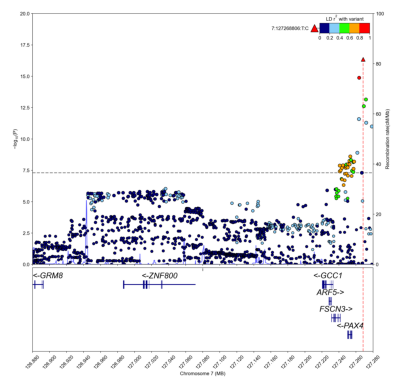

In [5]:
causal_row = sumstats.data.loc[sumstats.data["IS_CAUSAL"]].iloc[0]
pos = int(causal_row["POS"])
plot_region = (
    7,
    max(region[1], pos - 200_000),
    min(region[2], pos + 200_000),
)

out_dir = os.path.join(ROOT, "test", "output")
os.makedirs(out_dir, exist_ok=True)
regional_path = os.path.join(out_dir, "simulated_regional.png")

sumstats.plot_mqq(
    mode="r",
    region=plot_region,
    vcf_path=vcf_path,
    pinpoint=causal_ids,
    save=regional_path,
    verbose=False,
)
print(f"Saved: {regional_path}")
plt.imshow(plt.imread(regional_path))
plt.axis("off")

## Polygenic architecture

In [6]:
sumstats_poly, _ = gl.simulate_sumstats_region(
    vcf_path=vcf_path,
    region=region,
    n=10_000,
    mode="polygenic",
    pi=0.01,
    seed=42,
    build="19",
    verbose=False,
)

print(f"Causal variants: {sumstats_poly.data['IS_CAUSAL'].sum()}")

Causal variants: 23


## Binary trait (case–control)

In [7]:
sumstats_cc, _ = gl.simulate_sumstats_region(
    vcf_path=vcf_path,
    region=region,
    trait="binary",
    n_case=5_000,
    n_ctrl=5_000,
    n_causal=2,
    seed=42,
    build="19",
    verbose=False,
)

sumstats_cc.data.head(2)[["CHR", "POS", "N", "N_CASE", "N_CONTROL"]]

,CHR,POS,N,N_CASE,N_CONTROL
0,7,126753700,10000,5000,5000
1,7,126753750,10000,5000,5000


## Realism knobs

In [8]:
sumstats_inf, _ = gl.simulate_sumstats_region(
    vcf_path=vcf_path,
    region=region,
    n=10_000,
    n_causal=2,
    lambda_gc=1.1,
    seed=42,
    build="19",
    verbose=False,
)

sumstats_thin, _ = gl.simulate_sumstats_region(
    vcf_path=vcf_path,
    region=region,
    n=10_000,
    n_causal=2,
    seed=42,
    build="19",
    verbose=False,
    **REALISM_DEMO,
)

sumstats_full, _ = gl.simulate_sumstats_region(
    vcf_path=vcf_path,
    region=region,
    n=10_000,
    n_causal=2,
    thin=None,
    seed=42,
    build="19",
    verbose=False,
)
print(f"thin=0.5 (~50%): {len(sumstats_thin.data)} variants")
print(f"thin=None (all): {len(sumstats_full.data)} variants")

thin=0.5 (~50%): 1207 variants
thin=None (all): 2414 variants


## Downstream use

In [9]:
sumstats.basic_check(verbose=False)

,SNPID,CHR,POS,EA,NEA,STATUS,EAF,INFO,BETA,SE,Z,P,MLOG10P,N,N_EFF,IS_CAUSAL,BETA_TRUE
0,7:126753700:G:A,7,126753700,A,G,1960099,0.074405,0.965236,0.007709,0.010178,0.757409,4.488048e-01,0.347943,10000,9652.358540,False,0.0
1,7:126753750:G:A,7,126753750,A,G,1960099,0.062500,0.898001,0.009401,0.010553,0.890855,3.730069e-01,0.428283,10000,8980.007947,False,0.0
2,7:126755062:G:T,7,126755062,T,G,1960099,0.074405,0.987523,0.007727,0.010063,0.767829,4.425886e-01,0.354000,10000,9875.225598,False,0.0
3,7:126756466:G:A,7,126756466,A,G,1960099,0.074405,0.997028,0.007734,0.010015,0.772238,4.399736e-01,0.356573,10000,9970.282358,False,0.0
4,7:126756965:G:A,7,126756965,A,G,1960099,0.074405,0.852448,0.007611,0.010831,0.702726,4.822267e-01,0.316749,10000,8524.482406,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2409,7:127750016:C:T,7,127750016,T,C,1960099,0.148810,0.923214,0.072550,0.010408,6.970865,3.149975e-12,11.501693,10000,9232.142564,False,0.0
2410,7:127750722:G:A,7,127750722,A,G,1960099,0.016865,0.904948,0.022087,0.010512,2.101145,3.562827e-02,1.448205,10000,9049.482985,False,0.0
2411,7:127751678:C:CTTTTTTTT,7,127751678,CTTTTTTTT,C,1960399,0.113095,1.000000,0.065257,0.010000,6.525663,6.770141e-11,10.169402,10000,10000.000000,False,0.0
2412,7:127752202:G:A,7,127752202,A,G,1960099,0.082341,0.864861,-0.026035,0.010753,-2.421218,1.546858e-02,1.810549,10000,8648.610694,False,0.0


## Global simulation (full genome)

Uses the full `1kg_eas_hg19` reference panel (`vcf_path_gw`). All chromosomes in the VCF are simulated with `h2` calibration. This can take several minutes.

In [10]:
sumstats_gw, causals_gw = gl.simulate_sumstats_global(
    vcf_path=vcf_path_gw,
    n=10_000,
    mode="sparse",
    n_causal=3,
    h2=0.01,
    seed=42,
    build="19",
    verbose=False,
    **REALISM_DEMO,
)

print(f"Variants: {len(sumstats_gw.data)}")
print(f"Causals: {len(causals_gw)}")

Variants: 4304671
Causals: 3


## Visualize: Manhattan plot

Plot the genome-wide global simulation and highlight ground-truth causal variants.

Saved: /home/yunye/work/gwaslab/test/output/simulated_manhattan.png


(-0.5, 2469.5, 901.5, -0.5)

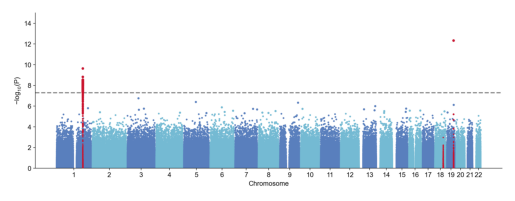

In [11]:
sumstats_gw.basic_check(verbose=False)
manhattan_path = os.path.join(out_dir, "simulated_manhattan.png")

sumstats_gw.plot_mqq(
    mode="m",
    highlight=causals_gw,
    save=manhattan_path,
    verbose=False,
)
print(f"Saved: {manhattan_path}")
plt.imshow(plt.imread(manhattan_path))
plt.axis("off")